In [1]:
import fastbook
fastbook.setup_book()

In [2]:
from fastbook import *
from pandas.api.types import is_string_dtype, is_numeric_dtype, is_categorical_dtype
from fastai.tabular.all import *
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from dtreeviz.trees import *
from IPython.display import Image, display_svg, SVG

pd.options.display.max_rows = 20
pd.options.display.max_columns = 8

In [3]:
from pathlib import Path
import pandas as pd

In [4]:
path =Path( '/home/z004psfe/projects/Fastai_coursework/9.tabular_tree_ensembles/bluebook-for-bulldozers')

In [5]:
to = load_pickle(path/'to.pkl')

In [6]:
xs,y = to.train.xs,to.train.y
valid_xs,valid_y = to.valid.xs,to.valid.y

In [7]:
to.items['Coupler_System'].head(10)

0    0
1    0
2    1
3    0
4    1
5    0
6    0
7    0
8    0
9    0
Name: Coupler_System, dtype: int8

In [8]:
xs,y = to.train.xs,to.train.y
valid_xs,valid_y = to.valid.xs,to.valid.y

In [9]:
m = DecisionTreeRegressor(max_leaf_nodes=4)
m.fit(xs, y);

In [10]:
dep_var = 'SalePrice'

In [11]:
#conda install -c conda-forge python-graphviz

In [12]:
import dtreeviz

In [13]:
xs.loc[xs['YearMade']<1900, 'YearMade'] = 1950
valid_xs.loc[valid_xs['YearMade']<1900, 'YearMade'] = 1950

In [14]:
m = DecisionTreeRegressor()
m.fit(xs, y);

In [15]:
def r_mse(pred,y): return round(math.sqrt(((pred-y)**2).mean()), 6)
def m_rmse(m, xs, y): return r_mse(m.predict(xs), y)

In [16]:
m_rmse(m, xs, y)

0.0

In [17]:
m_rmse(m, valid_xs, valid_y)

0.32943

In [18]:
m.get_n_leaves(), len(xs)

(np.int64(324344), 404710)

In [19]:
m = DecisionTreeRegressor(min_samples_leaf=25)
m.fit(to.train.xs, to.train.y)
m_rmse(m, xs, y), m_rmse(m, valid_xs, valid_y)

(0.243019, 0.30936)

In [20]:
def rf(xs, y, n_estimators=40, max_samples=200_000,
       max_features=0.5, min_samples_leaf=5, **kwargs):
    return RandomForestRegressor(n_jobs=-1, n_estimators=n_estimators,
        max_samples=max_samples, max_features=max_features,
        min_samples_leaf=min_samples_leaf, oob_score=True).fit(xs, y)

In [21]:
m = rf(xs, y);


In [22]:
m_rmse(m, xs, y), m_rmse(m, valid_xs, valid_y)

(0.171331, 0.232621)

In [23]:
preds = np.stack([t.predict(valid_xs) for t in m.estimators_])

/home/z004psfe/miniforge3/lib/python3.14/site-packages/sklearn/utils/validation.py:2823: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
/home/z004psfe/miniforge3/lib/python3.14/site-packages/sklearn/utils/validation.py:2823: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
/home/z004psfe/miniforge3/lib/python3.14/site-packages/sklearn/utils/validation.py:2823: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
/home/z004psfe/miniforge3/lib/python3.14/site-packages/sklearn/utils/validation.py:2823: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
/home/z004psfe/miniforge3/lib/python3.14/site-packages/sklearn/utils/validation.py:2823: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
/home/z004psfe/miniforge3/lib/python3.14/site-packages/sklearn/utils/validation.py:2823: U

In [24]:
r_mse(preds.mean(0), valid_y)

0.232621

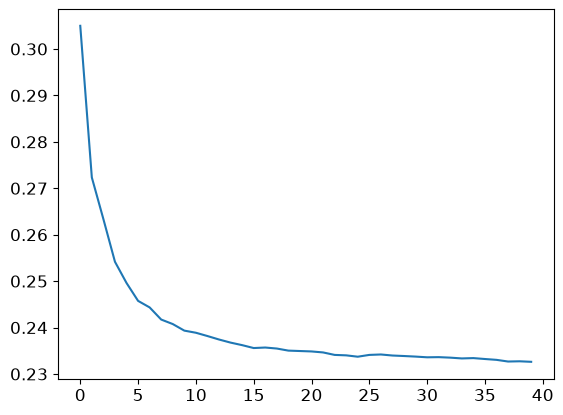

In [25]:
plt.plot([r_mse(preds[:i+1].mean(0), valid_y) for i in range(40)]);

In [26]:
r_mse(m.oob_prediction_, y)

0.211231

In [27]:
preds = np.stack([t.predict(valid_xs) for t in m.estimators_])

/home/z004psfe/miniforge3/lib/python3.14/site-packages/sklearn/utils/validation.py:2823: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
/home/z004psfe/miniforge3/lib/python3.14/site-packages/sklearn/utils/validation.py:2823: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
/home/z004psfe/miniforge3/lib/python3.14/site-packages/sklearn/utils/validation.py:2823: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
/home/z004psfe/miniforge3/lib/python3.14/site-packages/sklearn/utils/validation.py:2823: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
/home/z004psfe/miniforge3/lib/python3.14/site-packages/sklearn/utils/validation.py:2823: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
/home/z004psfe/miniforge3/lib/python3.14/site-packages/sklearn/utils/validation.py:2823: U

In [28]:
preds.shape

(40, 7988)

In [29]:
preds_std = preds.std(0)

In [30]:
preds_std[:5]

array([0.25915422, 0.12424009, 0.11996796, 0.24362901, 0.13341298])

In [31]:
def rf_feat_importance(m, df):
    return pd.DataFrame({'cols':df.columns, 'imp':m.feature_importances_}
                       ).sort_values('imp', ascending=False)

In [32]:
fi = rf_feat_importance(m, xs)
fi[:10]

,cols,imp
57,YearMade,0.170818
30,Coupler_System,0.110065
6,ProductSize,0.096737
7,fiProductClassDesc,0.087127
54,ModelID,0.056342
65,saleElapsed,0.051404
3,fiSecondaryDesc,0.049120
32,Hydraulics_Flow,0.048373
31,Grouser_Tracks,0.042956
12,Enclosure,0.041079


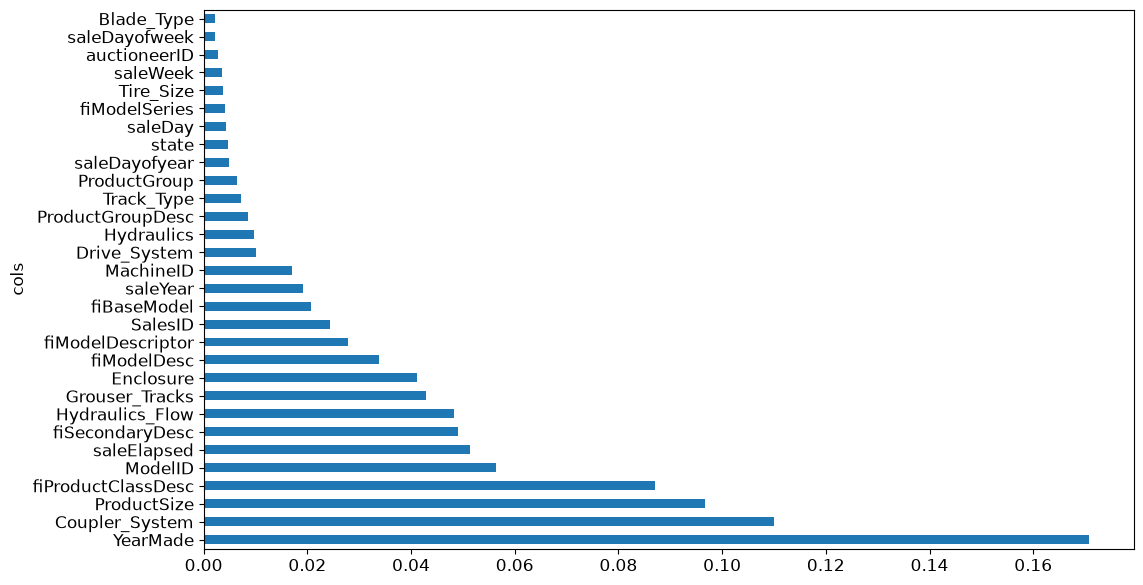

In [33]:
def plot_fi(fi):
    return fi.plot('cols', 'imp', 'barh', figsize=(12,7), legend=False)

plot_fi(fi[:30]);

In [34]:
to_keep = fi[fi.imp>0.005].cols
len(to_keep)

21

In [35]:
xs_imp = xs[to_keep]
valid_xs_imp = valid_xs[to_keep]

In [36]:
m = rf(xs_imp, y)

In [37]:
m_rmse(m, xs_imp, y), m_rmse(m, valid_xs_imp, valid_y)

(0.181966, 0.232291)

In [38]:
len(xs.columns), len(xs_imp.columns)

(66, 21)

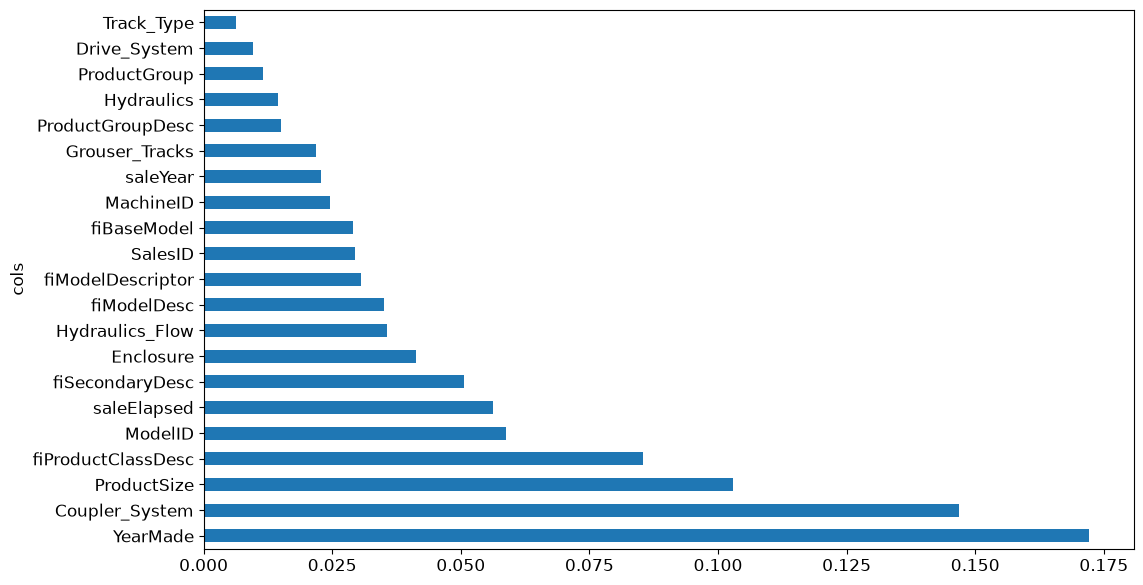

In [39]:
plot_fi(rf_feat_importance(m, xs_imp));

In [43]:
import scipy.spatial
import scipy.cluster.hierarchy as hc
hc.distance = scipy.spatial.distance

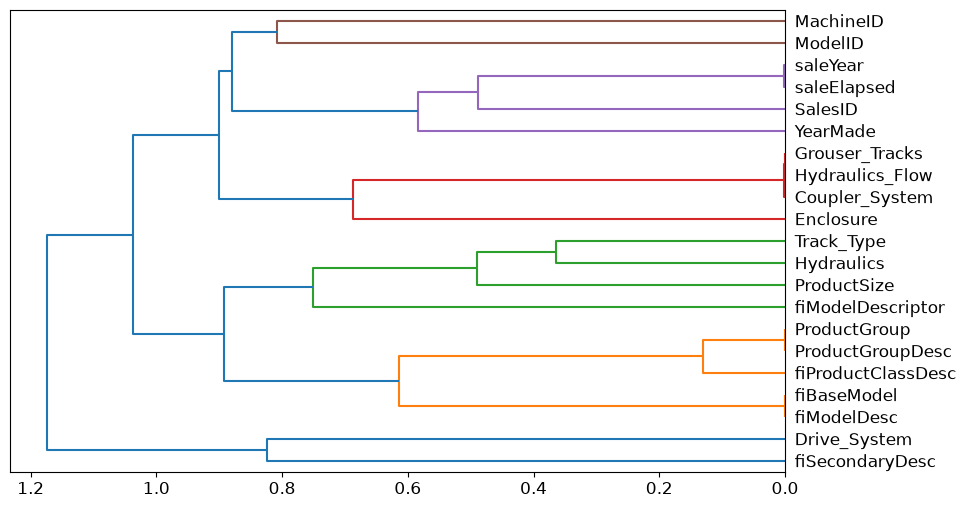

In [44]:
cluster_columns(xs_imp)

In [45]:
def get_oob(df):
    m = RandomForestRegressor(n_estimators=40, min_samples_leaf=15,
        max_samples=50000, max_features=0.5, n_jobs=-1, oob_score=True)
    m.fit(df, y)
    return m.oob_score_

In [46]:
get_oob(xs_imp)

0.8757534831234954

In [47]:
{c:get_oob(xs_imp.drop(c, axis=1)) for c in (
    'saleYear', 'saleElapsed', 'ProductGroupDesc','ProductGroup',
    'fiModelDesc', 'fiBaseModel',
    'Hydraulics_Flow','Grouser_Tracks', 'Coupler_System')}

{'saleYear': 0.8748841893480339,
 'saleElapsed': 0.8701773192464669,
 'ProductGroupDesc': 0.8766602112476333,
 'ProductGroup': 0.875723616594643,
 'fiModelDesc': 0.874257741551028,
 'fiBaseModel': 0.8747564891893512,
 'Hydraulics_Flow': 0.8763371110844114,
 'Grouser_Tracks': 0.8764419752459699,
 'Coupler_System': 0.8757385122354702}

In [48]:
to_drop = ['saleYear', 'ProductGroupDesc', 'fiBaseModel', 'Grouser_Tracks']
get_oob(xs_imp.drop(to_drop, axis=1))

0.8727237545448069

In [49]:
xs_final = xs_imp.drop(to_drop, axis=1)
valid_xs_final = valid_xs_imp.drop(to_drop, axis=1)

In [50]:
save_pickle(path/'xs_final.pkl', xs_final)
save_pickle(path/'valid_xs_final.pkl', valid_xs_final)

In [51]:
xs_final = load_pickle(path/'xs_final.pkl')
valid_xs_final = load_pickle(path/'valid_xs_final.pkl')

In [52]:
m = rf(xs_final, y)
m_rmse(m, xs_final, y), m_rmse(m, valid_xs_final, valid_y)

(0.183986, 0.233539)

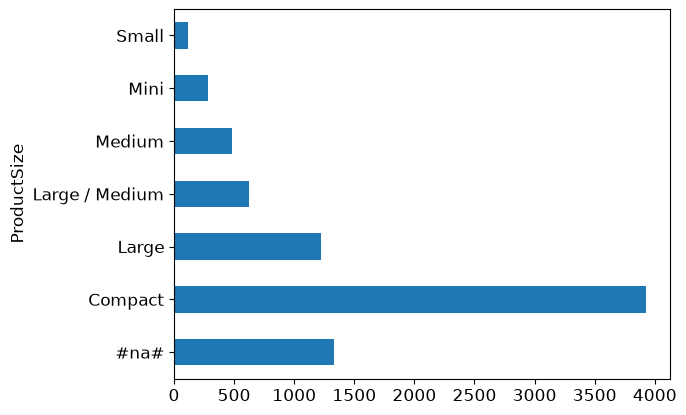

In [53]:
p = valid_xs_final['ProductSize'].value_counts(sort=False).plot.barh()
c = to.classes['ProductSize']
plt.yticks(range(len(c)), c);

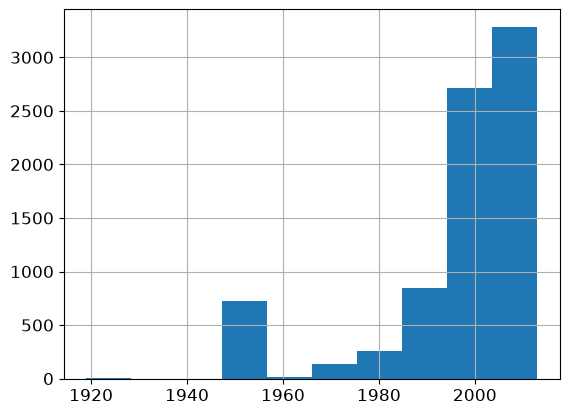

In [54]:
ax = valid_xs_final['YearMade'].hist()

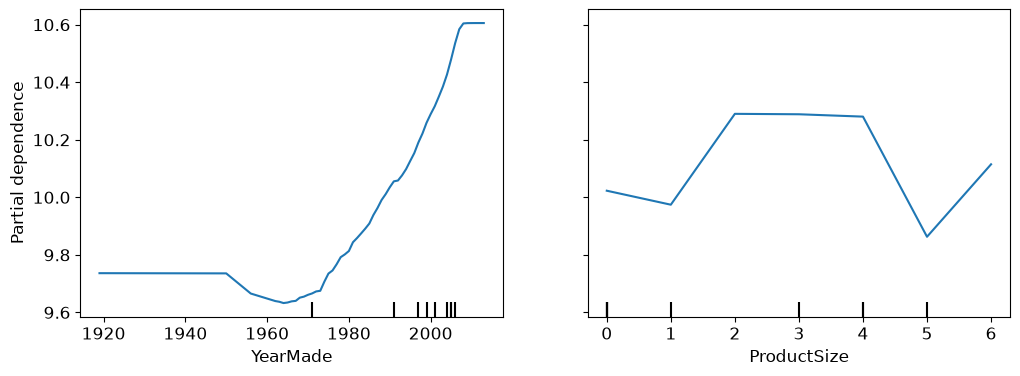

In [58]:
from sklearn.inspection import PartialDependenceDisplay

# 1. Cast integer columns to floats
features_to_plot = ['YearMade', 'ProductSize']
valid_xs_final_float = valid_xs_final.copy()
valid_xs_final_float[features_to_plot] = valid_xs_final_float[features_to_plot].astype(float)

# 2. Run the plot with the modified dataframe
fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    m, valid_xs_final_float, features_to_plot, ax=ax
)

In [61]:
!pip install treeinterpreter
!pip install waterfallcharts

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for waterfallcharts: filename=waterfallcharts-3.8-py3-none-any.whl size=3423 sha256=c470f0b585647bd8e28ecdbdc75353301d0bda44f28e1d045b9c7c6fbbaa0e3e
  Stored in directory: /home/z004psfe/.cache/pip/wheels/cd/f8/b8/7d37267c5819f29e8acd5265320793fe6a3fcd4b84861823df
Successfully built waterfallcharts


In [64]:
import warnings
warnings.simplefilter('ignore', FutureWarning)

from treeinterpreter import treeinterpreter
from waterfall_chart import plot as waterfall

In [69]:
row = valid_xs_final.iloc[:5]

In [76]:
np.random.seed(42)



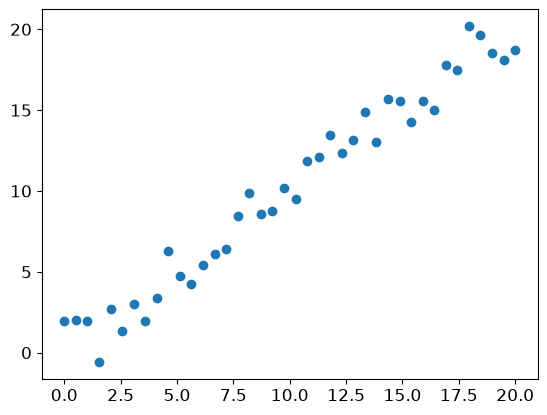

In [77]:
x_lin = torch.linspace(0,20, steps=40)
y_lin = x_lin + torch.randn_like(x_lin)
plt.scatter(x_lin, y_lin);

In [78]:
xs_lin = x_lin.unsqueeze(1)
x_lin.shape,xs_lin.shape

(torch.Size([40]), torch.Size([40, 1]))

In [79]:
m_lin = RandomForestRegressor().fit(xs_lin[:30],y_lin[:30])

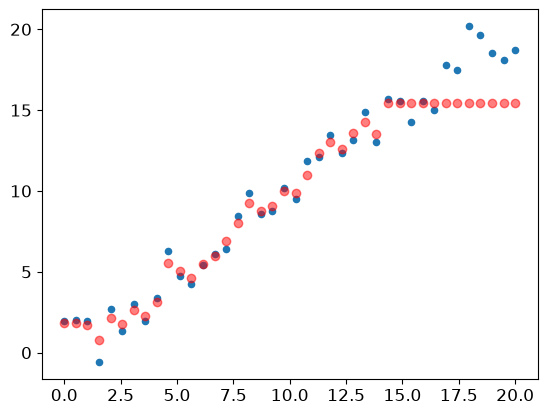

In [80]:
plt.scatter(x_lin, y_lin, 20)
plt.scatter(x_lin, m_lin.predict(xs_lin), color='red', alpha=0.5);

In [81]:
df_dom = pd.concat([xs_final, valid_xs_final])
is_valid = np.array([0]*len(xs_final) + [1]*len(valid_xs_final))

m = rf(df_dom, is_valid)
rf_feat_importance(m, df_dom)[:6]

,cols,imp
5,saleElapsed,0.854117
11,SalesID,0.113978
12,MachineID,0.024497
0,YearMade,0.002955
4,ModelID,0.001058
3,fiProductClassDesc,0.000660


In [82]:
m = rf(xs_final, y)
print('orig', m_rmse(m, valid_xs_final, valid_y))

for c in ('SalesID','saleElapsed','MachineID'):
    m = rf(xs_final.drop(c,axis=1), y)
    print(c, m_rmse(m, valid_xs_final.drop(c,axis=1), valid_y))

orig 0.232239
SalesID 0.229878
saleElapsed 0.234587
MachineID 0.230989


In [83]:
m = rf(xs_final, y)
print('orig', m_rmse(m, valid_xs_final, valid_y))

for c in ('SalesID','saleElapsed','MachineID'):
    m = rf(xs_final.drop(c,axis=1), y)
    print(c, m_rmse(m, valid_xs_final.drop(c,axis=1), valid_y))

orig 0.23259
SalesID 0.231124
saleElapsed 0.236746
MachineID 0.231152


In [84]:
time_vars = ['SalesID','MachineID']
xs_final_time = xs_final.drop(time_vars, axis=1)
valid_xs_time = valid_xs_final.drop(time_vars, axis=1)

m = rf(xs_final_time, y)
m_rmse(m, valid_xs_time, valid_y)

0.230276

In [86]:
sizes = 'Large','Large / Medium','Medium','Small','Mini','Compact'

In [88]:
df_nn = pd.read_csv(path/'TrainAndValid.csv', low_memory=False)
df_nn['ProductSize'] = df_nn['ProductSize'].astype('category')
df_nn['ProductSize'].cat.set_categories(sizes, ordered=True)
df_nn[dep_var] = np.log(df_nn[dep_var])
df_nn = add_datepart(df_nn, 'saledate')

In [89]:
df_nn_final = df_nn[list(xs_final_time.columns) + [dep_var]]

In [90]:
cont_nn,cat_nn = cont_cat_split(df_nn_final, max_card=9000, dep_var=dep_var)

In [91]:
cont_nn

['saleElapsed']

In [92]:
df_nn_final[cat_nn].nunique()

YearMade                73
Coupler_System           2
ProductSize              6
fiProductClassDesc      74
ModelID               5281
fiSecondaryDesc        177
Hydraulics_Flow          3
Enclosure                6
fiModelDesc           5059
fiModelDescriptor      140
Drive_System             4
Hydraulics              12
Track_Type               2
ProductGroup             6
dtype: int64

In [94]:
cat_nn.remove('fiModelDescriptor')